In [2]:
import numpy as np
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import pymaster as nmt
from astropy.io import fits
from astropy.table import Table
from astropy.utils.data import get_pkg_data_filename

# load the RGB values from file
from matplotlib.colors import ListedColormap

nside = 2048 #resolution of the map in pixels

#importing useful libraries

In [3]:
hdul = fits.open("COM_CMB_IQU-smica-nosz_2048_R3.00_full.fits")
#hdul.info()
#print(hdul[0].header)   # primary header cards
print(hdul[1].header)   # table header cards


XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / 8-bit bytes                                    NAXIS   =                    2 / 2-dimensional binary table                     NAXIS1  =                    8 / width of table in bytes                        NAXIS2  =             50331648 / number of rows in table                        PCOUNT  =                    0 / size of special data area                      GCOUNT  =                    1 / one data group (required keyword)              TFIELDS =                    2 / number of fields in each row                   COMMENT  -------------------------------------------------------------          COMMENT  Products from SMICA component separation method                        COMMENT  -------------------------------------------------------------          COMMENT  Further details in the Planck Legacy Archive and Explanatory SupplementCOMMENT  http://www.cosmos.esa.int/web/p

In [4]:
cmb_data = hdul[1].data["I_STOKES"]   #extracting temperature map from the data

#print(cmb_data.shape)     # should be (50331648,)
#print(hp.get_nside(cmb_data))   # should be 2048

# hp.mollview(cmb_data, title="Planck SMICA CMB Map", unit="K_CMB")
# plt.show()

# hp.mollview(cmb_data * 1e6, title="Planck SMICA CMB Map", unit="uK_CMB", min=-300, max=300)
# plt.show()

# hp.mollview(cmb_data, title="Planck SMICA CMB Map", unit="K_CMB", min=-3e-4, max=3e-4)
# plt.show()

In [5]:
with fits.open("COM_CMB_IQU-smica-nosz_2048_R3.00_full.fits") as hdul:
    data = hdul[1].data
    hdr = hdul[1].header

T = np.array(data["I_STOKES"], dtype=np.float64) #array of temperature values in the map

# the smica map is in NESTED ordering; map2alm should use RING ordering
if hdr["ORDERING"].strip() == "NESTED":
    T = hp.reorder(T, n2r=True)

nside = hdr["NSIDE"]
l_max = 3000

alm = hp.map2alm(T, lmax=l_max, pol=False)
alm


# hp.mollview(T, title="raw map", min=-3e-4, max=3e-4)


array([ 1.99502496e-13+0.00000000e+00j,  6.34993770e-12+0.00000000e+00j,
        1.28046700e-05+0.00000000e+00j, ...,
       -1.85063461e-09+5.62856028e-09j,  8.83377318e-10+8.19236774e-09j,
        2.62906262e-09+6.18808315e-09j], shape=(4504501,))

In [6]:
# T_smooth = hp.smoothing(T, fwhm=np.radians(5.0))
# hp.mollview(T_smooth, title="smoothed map", min=-3e-5, max=3e-5)

In [7]:
cl = hp.alm2cl(alm)      # angular power spectrum C_l
#T_rec = hp.alm2map(alm, nside=nside, lmax=lmax, verbose=False)  # reconstruct map
cl

array([3.98012460e-26, 1.34527742e-23, 1.87550512e-10, ...,
       1.80485623e-16, 1.76318120e-16, 1.74511470e-16], shape=(3001,))

In [8]:
ell = np.arange(len(cl))

# plt.figure(figsize=(8,5))
# plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi))
# plt.xlabel(r"$\ell$")
# plt.xlim(2, 3000)
# plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# # plt.xscale('log')
# # plt.yscale('log')
# # Setting X and Y axis data points
# x = [ell]
# y = [cl]

# # plotting the points on the graph
# # plt.plot(x,y)
# plt.title("temperature power spectrum")
# plt.grid(alpha=0.3)
# plt.show()


In [9]:
mask = np.loadtxt("filter.txt") #2D array that contains ell in first column and mask values in second column
print(mask.shape)

FWMN = 5.0  # Full Width at Half Maximum of the beam in arcminutes
FWHM = FWMN * np.pi / (180 * 60)  # convert FWHM from arcminutes to radians

ell = np.arange(3001)
beam = np.exp(-0.5 * ell * (ell + 1) * (FWHM / np.sqrt((8 * np.log(2))))**2)

filter = mask[:, 1] * beam

# plt.figure(figsize=(8,5))
# plt.plot(ell, filter, label="filter")
# plt.plot(ell, mask[:, 1], label="mask")
# plt.plot(ell, beam, label="beam")
# plt.xlabel(r"$\ell$")
# plt.ylabel("filter")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

(3001, 2)


In [10]:
#print(cl.shape)

alm_filtered = hp.almxfl(alm, filter)
print(alm_filtered.shape)

(4504501,)


In [11]:
# temp = np.empty((0, 2))   # empty array with 2 columns

# ell = np.arange(3001)
# alm = alm[:3001]

# temp = np.append(temp, np.column_stack((ell, alm)), axis=0)
# filter_ell = np.column_stack((ell, filter))

# print(temp.shape)   # (3001, 2)
# print(filter_ell.shape)


In [12]:
cl = hp.alm2cl(alm_filtered)    # angular power spectrum C_l of the filtered alm coefficients
ell = np.arange(len(cl))

# plt.figure(figsize=(8,5))
# plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * cl[2:] / (2*np.pi), label='Filtered')
# plt.xlabel(r"$\ell$")
# plt.ylabel(r"$D_\ell$")
# plt.title("Temperature power spectrum")
# plt.grid(alpha=0.3)
# plt.show()


In [ ]:
masked_temp = hp.alm2map(alm_filtered, nside=nside, lmax=l_max)  # reconstruct map from filtered alm coefficients

# custom colormap
colors = np.loadtxt("color_map.txt") / 255.0
cmap = ListedColormap(colors)
cmap.set_bad("white")
cmap.set_under("white")


# remove monopole/dipole
cmb_clean = hp.remove_dipole(masked_temp)
cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

# choose visualization range
sigma = np.std(cmb_clean)

hp.mollview(
    cmb_clean,
    cmap=cmap,
    min=-3e-5,
    max=3e-5,
    title="filtered CMB map",
    bgcolor="white",
    badcolor="white",
    unit="muK"
)

plt.show()


NameError: name 'hp' is not defined

In [ ]:
# masked_temp_smooth = hp.smoothing(masked_temp, fwhm=np.radians(5.0))
# hp.mollview(masked_temp_smooth, title="smoothed map")

In [ ]:
# hdul=fits.open("1_delta.fits")
# hdul.info()
# # print(hdul[0].header)   # primary header cards
# # print(hdul[1].header)   # table header cards



In [ ]:
# hdul = fits.open("1_delta.fits")
# data = hdul[1].data
# # print(data)

# galaxy_data = hdul[1].data
# image_header = hdul[1].header
# # print(galaxy_data.shape)


In [ ]:
# with fits.open("1_delta.fits") as hdul:
#     data = hdul[1].data

# G_chunks = data["T"]   # shape: (49152, 1024)

In [ ]:
# G = G_chunks.reshape(-1)

In [ ]:
# hp.nside2npix(nside) == len(T)
# # should return True

In [ ]:
# hp.mollview(T, title="Galaxy overdensity")

In [ ]:
# alm_gal = hp.map2alm(T, lmax=3*nside-1)

In [ ]:
# cl_gal = hp.alm2cl(alm_gal)
# # ell_gal = np.arange(len(cl_gal))

# # plt.figure(figsize=(8,5))
# # plt.plot(ell_gal[2:], ell_gal[2:] * (ell_gal[2:] + 1) * cl_gal[2:] / (2*np.pi))
# # plt.xlabel(r"$\ell$")
# # plt.xlim(2, 2500)
# # plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# # plt.title("galaxy overdensity power spectrum")
# # plt.grid(alpha=0.3)
# # plt.show()


In [ ]:
# ell = np.arange(3001)
# c_ell = cl[:3001]
# c_ell_gal = cl_gal[:3001]

# kSZ = c_ell * c_ell_gal  # element-wise multiplication of C_l with the galaxy power spectrum
# plt.figure(figsize=(8,5))
# plt.plot(ell[2:], ell[2:] * (ell[2:] + 1) * kSZ[2:] / (2*np.pi))
# plt.xlabel(r"$\ell$")
# plt.xlim(2, 2500)
# plt.ylabel(r"$\ell(\ell+1)C_\ell / 2\pi$")
# plt.title("kSZ power spectrum")
# plt.grid(alpha=0.3)
# plt.show()

In [ ]:
# cmb_map = hp.alm2map(alm, nside=nside, lmax=l_max)  # reconstruct map from filtered alm coefficients

# hp.mollview(cmb_map, title="Planck SMICA unfiltered CMB Map", unit="K_CMB", min=-500e-6, max=500e-6)
# plt.show()

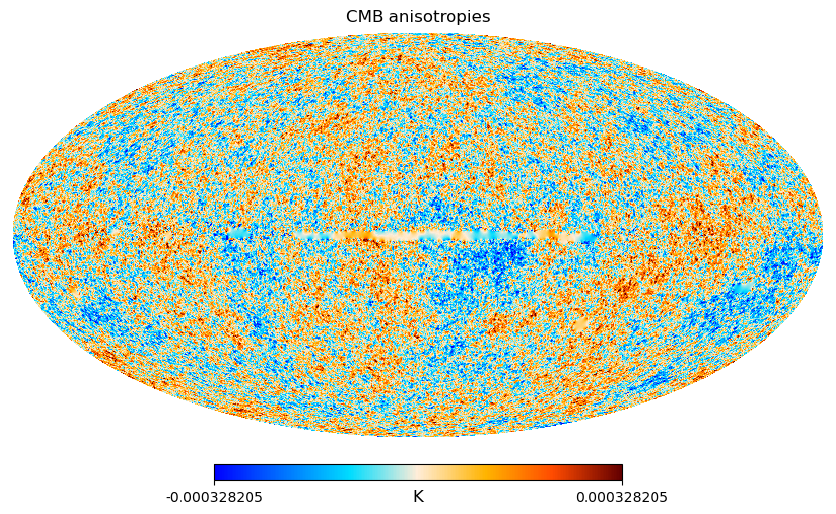

In [ ]:
# custom colormap
colors = np.loadtxt("color_map.txt") / 255.0
cmap = ListedColormap(colors)
cmap.set_bad("white")
cmap.set_under("white")


# remove monopole/dipole
cmb_clean = hp.remove_dipole(T)
cmb_clean = np.where(cmb_clean == hp.UNSEEN, np.nan, cmb_clean)

# choose visualization range
sigma = np.std(cmb_clean)

hp.mollview(
    cmb_clean,
    cmap=cmap,
    min=-3*sigma,
    max=3*sigma,
    title="CMB anisotropies",
    bgcolor="white",
    badcolor="white",
    unit="K"
)